In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import ParameterGrid


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    fbeta_score
)

In [25]:
df = pd.read_csv("../../../data/processed/feature_dataset.csv")

In [26]:
# One hot encoding for age and recording location
df = pd.get_dummies(df, columns=["Age"], drop_first=True)

df = pd.get_dummies(df, columns=["recording_location"], drop_first=True)

df = pd.get_dummies(df, columns=["Murmur"], drop_first=True)

df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

df["Outcome"] = df["Outcome"].map({
    "Normal": 0,
    "Abnormal": 1
})

print(df.columns.tolist())

['Patient ID', 'Outcome', 'split', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'file', 'Campaign', 'Additional ID', 'rms', 'peak', 'variance', 'mean', 'std', 'skew', 'kurtosis', 'zcr', 'dynamic_range', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flatness', 'band_energy_20_50', 'band_energy_50_100', 'band_energy_100_200', 'band_energy_200_400', 'band_energy_400_800', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_d1_1_mean', 'mfcc_d1_1_std', 'mfcc_d2_1_mean', 'mfcc_d2_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_d1_2_mean', 'mfcc_d1_2_std', 'mfcc_d2_2_mean', 'mfcc_d2_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_d1_3_mean', 'mfcc_d1_3_std', 'mfcc_d2_3_mean', 'mfcc_d2_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_d1_4_mean', 'mfcc_d1_4_std', 'mfcc_d2_4_mean', 'mfcc_d2_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_d1_5_mean', 'mfcc_d1_5_std', 'mfcc_d2_5_mean', 'mfcc_d2_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_d1_6_mean', 'mfcc_d1_6_std', 'mfcc_d2_6_mean', 'mfcc_d2_6_std', 'mfcc

In [27]:
# Iteratively remove features with high VIF

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

X_vif = X_train_df.copy()

X_vif = X_vif.astype(float)

while True:

    vif = pd.Series(
        [
            variance_inflation_factor(
                X_vif.values,
                i
            )
            for i in range(X_vif.shape[1])
        ],
        index=X_vif.columns
    )

    max_vif = vif.max()

    if max_vif < 10:
        break

    feature_to_drop = vif.idxmax()

    print(
        f"Dropping "
        f"{feature_to_drop}"
        f" (VIF={max_vif:.2f})"
    )

    X_vif = X_vif.drop(
        columns=[feature_to_drop]
    )

selected_vif_features = list(
    X_vif.columns
)

print(
    f"Remaining features: "
    f"{len(selected_vif_features)}"
)

Dropping peak (VIF=11788.83)
Dropping spectral_bandwidth (VIF=1948.29)
Dropping spectral_centroid (VIF=1102.05)
Dropping variance (VIF=221.23)
Dropping mfcc_12_std (VIF=215.30)
Dropping spectral_rolloff (VIF=197.95)
Dropping mfcc_8_std (VIF=188.65)
Dropping mfcc_10_std (VIF=172.52)
Dropping mfcc_6_std (VIF=172.10)
Dropping mfcc_13_std (VIF=166.55)
Dropping mfcc_9_std (VIF=160.09)
Dropping mfcc_1_std (VIF=148.43)
Dropping mfcc_11_std (VIF=142.91)
Dropping mfcc_7_std (VIF=138.95)
Dropping mfcc_5_std (VIF=128.43)
Dropping mfcc_d1_3_std (VIF=119.03)
Dropping mfcc_4_std (VIF=117.17)
Dropping mfcc_2_mean (VIF=104.35)
Dropping mfcc_d1_2_std (VIF=85.87)
Dropping mfcc_d2_12_std (VIF=83.01)
Dropping mfcc_d2_9_std (VIF=82.68)
Dropping mfcc_d2_6_std (VIF=82.11)
Dropping mfcc_d2_4_std (VIF=81.62)
Dropping mfcc_d2_11_std (VIF=78.15)
Dropping mfcc_d2_8_std (VIF=73.19)
Dropping mfcc_1_mean (VIF=70.56)
Dropping mfcc_d2_5_std (VIF=69.66)
Dropping mfcc_d2_13_std (VIF=68.41)
Dropping mfcc_3_std (VIF=68.37

In [28]:
# -----------------------------
# Split using your predefined split
# -----------------------------
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

In [29]:
# -----------------------------
# Prepare features
# -----------------------------
drop_cols = ["Patient ID", "Outcome", "split", "file", "Campaign", "Additional ID", "Height", "Weight"]

drop_cols = drop_cols + ["rms"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Outcome"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["Outcome"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Outcome"]


# 2. Apply feature subset
X_train = X_train[selected_vif_features]
X_val = X_val[selected_vif_features]
X_test = X_test[selected_vif_features]   

In [ ]:
# # Calculate correlation matrix
# corr_matrix = X_train.corr()

# # Get upper triangle only (avoid duplicate pairs and self-correlation)
# upper = corr_matrix.where(
#     np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
# )

# # Find highly correlated feature pairs
# high_corr = (
#     upper.stack()
#     .reset_index()
#     .rename(columns={
#         "level_0": "Feature 1",
#         "level_1": "Feature 2",
#         0: "Correlation"
#     })
# )

# # Sort by absolute correlation
# high_corr["Abs Correlation"] = high_corr["Correlation"].abs()

# high_corr = high_corr.sort_values(
#     by="Abs Correlation",
#     ascending=False
# )

# # Show correlations above threshold
# threshold = 0.9

# print(
#     high_corr[
#         high_corr["Abs Correlation"] >= threshold
#     ]
# )

In [ ]:
# # Plot heatmap of correlation matrix

# plt.figure(figsize=(14, 12))

# sns.heatmap(
#     corr_matrix,
#     cmap="coolwarm",
#     center=0
# )

# plt.title("Feature Correlation Matrix")
# plt.show()

In [30]:
# -----------------------------
# Scaling (IMPORTANT for linear models)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [32]:
# -----------------------------
# Models (Manually trying hyperparameters)
# -----------------------------
models = {
    "L2": LogisticRegression(
        penalty="l2",
        C=0.1,
        max_iter=4000
    ),

    "L1": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        max_iter=4000
    ),
    
    "weighted_L1": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        class_weight={
            0: 1,
            1: 2
        },
        max_iter=4000
    ),

    "ElasticNet": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=0.1,
        l1_ratio=0.5,
        max_iter=4000
    )
}

# Feature names after dropping unwanted columns
train_df_dropped = train_df.drop(columns=drop_cols)

# Store results
coefficients = {}

# Train and analyze models
for name, model in models.items():
    model.fit(X_train, y_train)

    coef = pd.Series(
        model.coef_[0],
        index=selected_vif_features
    )

    coefficients[name] = coef

In [33]:
# Features selected by each model
for name, coef in coefficients.items():
    print(f"\n{name} selected features:")
    print(coef[coef != 0].sort_values(key=abs, ascending=False))


L2 selected features:
Murmur_Present            0.781231
Pregnancy status         -0.311626
band_energy_100_200       0.251304
mfcc_7_mean              -0.198139
mfcc_d2_1_mean           -0.185748
recording_location_Phc    0.165732
mfcc_12_mean              0.148180
band_energy_50_100       -0.144501
Murmur_Unknown            0.126063
band_energy_400_800       0.117760
band_energy_20_50         0.114073
mfcc_d2_2_mean           -0.112348
Sex                      -0.107387
mfcc_d1_12_mean           0.100756
mfcc_d2_6_mean           -0.099322
Age_Child                -0.096863
mfcc_d1_6_mean            0.081075
mfcc_d1_9_std            -0.079567
mfcc_3_mean              -0.078572
mfcc_d1_5_mean            0.074070
mfcc_5_mean               0.069664
mfcc_d1_9_mean           -0.067902
mfcc_d2_8_mean           -0.060891
mfcc_9_mean              -0.058013
mfcc_10_mean             -0.051593
mfcc_d1_2_mean           -0.047187
skew                     -0.045848
band_energy_200_400      -0.0445

In [34]:
summary = pd.DataFrame({
    name: {
        "selected_features": (coef != 0).sum(),
        "zero_coefficients": (coef == 0).sum()
    }
    for name, coef in coefficients.items()
}).T

print(summary)

             selected_features  zero_coefficients
L2                          55                  0
L1                          39                 16
weighted_L1                 42                 13
ElasticNet                  49                  6


In [36]:
results = []

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Coefficients
    coef = pd.Series(
        model.coef_[0],
        index=selected_vif_features
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Features": (coef != 0).sum()
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("ROC-AUC", ascending=False))

         Model  Accuracy  Precision    Recall        F1   ROC-AUC  Features
1           L1  0.668776   0.766667  0.485232  0.594315  0.696790        39
3   ElasticNet  0.658228   0.735849  0.493671  0.590909  0.694369        49
2  weighted_L1  0.544304   0.526185  0.890295  0.661442  0.692304        42
0           L2  0.658228   0.724551  0.510549  0.599010  0.692143        55


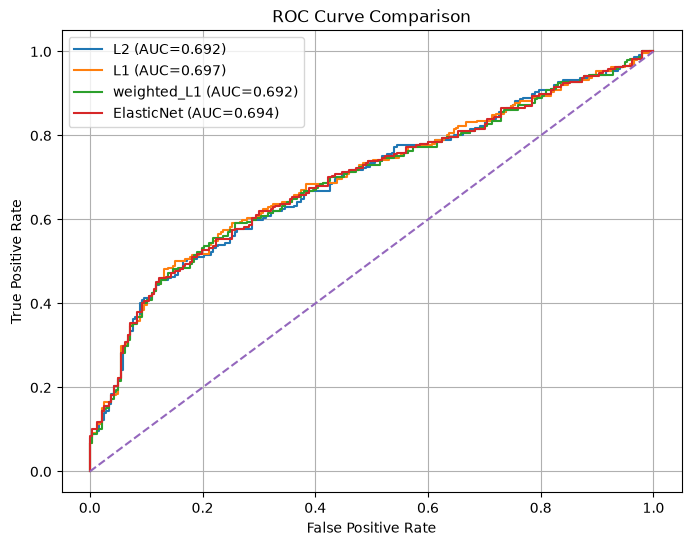

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

## GridSearch: Hyperparameter tuning
Tuning the hyperparameters to obtain a model that maximizes F2 score, while having a minimum precision of 0.5

### Why F2?

$F2 = 5 × \frac{Precision × Recall}{(4 × Precision) + Recall}$

* Prioritizing Recall: The F2 score is ideal for situations where missing a positive case (a false negative) carries a massive penalty compared to falsely flagging a negative case (a false positive).
* Use Cases: It is highly recommended in medical diagnoses (where failing to catch an illness is dangerous) and fraud detection (where missing a fraudulent transaction is costly).

In [38]:
param_grid = {
    "penalty": [
        "l1",
        "l2",
        "elasticnet"
    ],

    "C": [
        1e-5,
        1e-4,
        1e-3,
        1e-2,
        1e-1,
        1,
        10,
        100,
        1000
    ],

    "l1_ratio": [
        0.05,
        0.1,
        0.25,
        0.5,
        0.75,
        0.9,
        0.95
    ],

    "class_weight": [
        None,
        "balanced",
        {0:1, 1:2},
        {0:1, 1:3},
        {0:1, 1:5},
    ],

    "fit_intercept": [
        True,
        False
    ]
}

In [39]:
precision_targets = [0.5, 0.6, 0.7]

best_results = {
    p: {
        "f2": -1,
        "model": None,
        "params": None,
        "threshold": None,
        "precision": None,
        "recall": None
    }
    for p in precision_targets
}

In [40]:
import warnings
warnings.filterwarnings("ignore")

best_model = None
best_params = None
best_threshold = None

best_f2 = -1
best_recall = 0
best_precision = 0

min_precision = 0.5

for params in ParameterGrid(param_grid):

    params = params.copy()

    # Handle valid solver/penalty combinations
    if params["penalty"] == "elasticnet":
        solver = "saga"

    elif params["penalty"] == "l1":
        solver = "saga"
        params["l1_ratio"] = None

    else:  # l2
        solver = "lbfgs"
        params["l1_ratio"] = None

    print("\nTesting parameters:")
    print(params)

    model = LogisticRegression(
        penalty=params["penalty"],
        C=params["C"],
        solver=solver,
        class_weight=params["class_weight"],
        l1_ratio=params["l1_ratio"],
        max_iter=4000
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]

    for threshold in np.arange(0.05, 0.95, 0.01):

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(
            y_val,
            y_pred,
            zero_division=0
        )
        
        for target in precision_targets:

            if precision < target:
                continue
            
            recall = recall_score(y_val, y_pred)
            
            f2 = fbeta_score(
                y_val,
                y_pred,
                beta=2,
                zero_division=0
            )

            if f2 > best_results[target]["f2"]:

                best_results[target]["f2"] = f2
                best_results[target]["model"] = model
                best_results[target]["params"] = params.copy()
                best_results[target]["threshold"] = threshold
                best_results[target]["precision"] = precision
                best_results[target]["recall"] = recall

                print(
                    f"[P>={target}] "
                    f"F2={f2:.3f} "
                    f"P={precision:.3f} "
                    f"R={recall:.3f} "
                    f"T={threshold:.2f}"
                )

for target in precision_targets:

    result = best_results[target]

    print("\n==========================")
    print(f"BEST MODEL (Precision ≥ {target})")
    print("==========================")

    print("Parameters:")
    print(result["params"])

    print(f"Threshold: {result['threshold']:.2f}")
    print(f"F2 Score : {result['f2']:.3f}")
    print(f"Precision: {result['precision']:.3f}")
    print(f"Recall   : {result['recall']:.3f}")


Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l1'}

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l2'}
[P>=0.5] F2=0.062 P=1.000 R=0.050 T=0.49
[P>=0.6] F2=0.062 P=1.000 R=0.050 T=0.49
[P>=0.7] F2=0.062 P=1.000 R=0.050 T=0.49

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': 0.05, 'penalty': 'elasticnet'}

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l1'}

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l2'}

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': 0.1, 'penalty': 'elasticnet'}

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l1'}

Testing parameters:
{'C': 1e-05, 'class_weight': None, 'fit_int

In [41]:
for target in precision_targets:

    result = best_results[target]

    print("\n==========================")
    print(f"BEST MODEL (Precision ≥ {target})")
    print("==========================")

    print("Parameters:")
    print(result["params"])

    print(f"Threshold: {result['threshold']:.2f}")
    print(f"F2 Score : {result['f2']:.3f}")
    print(f"Precision: {result['precision']:.3f}")
    print(f"Recall   : {result['recall']:.3f}")


BEST MODEL (Precision ≥ 0.5)
Parameters:
{'C': 0.001, 'class_weight': {0: 1, 1: 2}, 'fit_intercept': True, 'l1_ratio': 0.05, 'penalty': 'elasticnet'}
Threshold: 0.59
F2 Score : 0.838
Precision: 0.513
Recall   : 0.995

BEST MODEL (Precision ≥ 0.6)
Parameters:
{'C': 0.01, 'class_weight': {0: 1, 1: 3}, 'fit_intercept': True, 'l1_ratio': 0.5, 'penalty': 'elasticnet'}
Threshold: 0.68
F2 Score : 0.712
Precision: 0.618
Recall   : 0.740

BEST MODEL (Precision ≥ 0.7)
Parameters:
{'C': 0.01, 'class_weight': {0: 1, 1: 3}, 'fit_intercept': True, 'l1_ratio': 0.25, 'penalty': 'elasticnet'}
Threshold: 0.70
F2 Score : 0.631
Precision: 0.720
Recall   : 0.612


When minimizing for F2:

```py

==========================
BEST MODEL (Precision ≥ 0.5)
==========================
Parameters:
{'C': 10, 'class_weight': {0: 1, 1: 2}, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l2'}
Threshold: 0.42
F2 Score : 0.824
Precision: 0.516
Recall   : 0.968

==========================
BEST MODEL (Precision ≥ 0.6)
==========================
Parameters:
{'C': 0.001, 'class_weight': 'balanced', 'fit_intercept': True, 'l1_ratio': 0.75, 'penalty': 'elasticnet'}
Threshold: 0.49
F2 Score : 0.656
Precision: 0.602
Recall   : 0.671

==========================
BEST MODEL (Precision ≥ 0.7)
==========================
Parameters:
{'C': 100, 'class_weight': {0: 1, 1: 5}, 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l2'}
Threshold: 0.84
F2 Score : 0.574
Precision: 0.710
Recall   : 0.548

==========================
BEST MODEL (Precision ≥ 0.8)
==========================
Parameters:
{'C': 1, 'class_weight': 'balanced', 'fit_intercept': True, 'l1_ratio': None, 'penalty': 'l2'}
Threshold: 0.59
F2 Score : 0.508
Precision: 0.803
Recall   : 0.466

```

In [42]:
# Retrain best model on train and validation data

X_trainval = pd.concat(
    [X_train, X_val],
    axis=0,
    ignore_index=True
)

y_trainval = pd.concat(
    [y_train, y_val],
    axis=0,
    ignore_index=True
)

best_lr_model = LogisticRegression(
    penalty="l2",
    C=10,
    class_weight={0: 1, 1: 2},
    max_iter=4000
)

best_lr_model.fit(
    X_trainval,
    y_trainval
)

threshold = 0.42

y_prob = best_lr_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= threshold).astype(int)

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

In [ ]:
# Benchmarking metrics on Test Set
# DO NOT FINE TUNE MODEL BASED ON THESE RESULTS
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F2:", fbeta_score(
                y_test,
                y_pred,
                beta=2,
                zero_division=0
            )
    )
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

```py
Precision: 0.5216346153846154
Recall: 0.9156118143459916
F2: 0.7954545454545454
ROC-AUC: 0.6925528316331072
[[ 38 199]
 [ 20 217]]
```

## Benchmarking

### Precision Recall Curve

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score
)

# Probabilities
y_prob = best_lr_model.predict_proba(X_test)[:, 1]

# PR curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

# Chosen operating point
y_pred = (y_prob >= best_threshold).astype(int)

selected_precision = precision_score(
    y_test,
    y_pred
)

selected_recall = recall_score(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR Curve (AP = {ap:.3f})"
)

plt.scatter(
    selected_recall,
    selected_precision,
    s=120,
    marker="X",
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (
    y_prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()